# Section 5 Model Evaluation

In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
# Load the Data

X_train = pd.read_csv('Data/Splitting/Train/Generic/X/X_train.csv')
y_train_fso = pd.read_csv('Data/Splitting/Train/Generic/y/y_train_FSO.csv')
y_train_rf = pd.read_csv('Data/Splitting/Train/Generic/y/y_train_RF.csv')

X_val = pd.read_csv('Data/Splitting/Validation/Generic/X/X_val.csv')
y_val_fso = pd.read_csv('Data/Splitting/Validation/Generic/y/y_val_FSO.csv')
y_val_rf = pd.read_csv('Data/Splitting/Validation/Generic/y/y_val_RF.csv')

# Combine training and validation feature sets
X_new_train = pd.concat([X_train, X_val], axis=0, ignore_index=True)

# Combine training and validation target sets for FSO and RF
y_new_train_fso = pd.concat([y_train_fso, y_val_fso], axis=0, ignore_index=True)
y_new_train_rf = pd.concat([y_train_rf, y_val_rf], axis=0, ignore_index=True)



X_test = pd.read_csv('Data/Splitting/Test/Generic/X/X_test.csv')
y_test_rf = pd.read_csv('Data/Splitting/Test/Generic/y/y_test_RF.csv')
y_test_fso = pd.read_csv('Data/Splitting/Test/Generic/y/y_test_FSO.csv')

In [3]:
# Load the 1st rf model saved metadata
saved_model1 = joblib.load('saved_models/method2/best_model1_fsoprediction.pkl')
saved_model2 = joblib.load('saved_models/method2/best_model2_rfprediction.pkl')


# Extract the best parameters
best_params1 = saved_model1['Best Params']
best_params2 = saved_model2['Best Params']

In [4]:
# Reconstruct the Random Forest model with the best parameters
rf_model1 = RandomForestRegressor(
    n_estimators=best_params1['n_estimators'],
    max_depth=best_params1['max_depth'],
    min_samples_split=best_params1['min_samples_split'],
    min_samples_leaf=best_params1['min_samples_leaf'],
    random_state=42  # Ensure reproducibility
)

# Train the reconstructed model on the training data
# Define the selected important features
selected_features1 = ['AH', 'Vis_Min', 'Part_Min', 'Temp', 'Vis', 'Dist']

# Filter columns for both training and FSO input
X_new_train_selected = X_new_train[selected_features1]

rf_model1.fit(X_new_train_selected, y_new_train_fso)

/Users/ruyuliu/anaconda3/envs/nlp_course/lib/python3.11/site-packages/sklearn/base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(n_estimators=200, random_state=42)

In [5]:
# === Predict FSO attenuation ===
X_test_selected = X_test[selected_features1]

predicted_fso_test = rf_model1.predict(X_test_selected)

In [6]:
# Reconstruct the Random Forest model with the best parameters
rf_model2 = RandomForestRegressor(
    n_estimators=best_params2['n_estimators'],
    max_depth=best_params2['max_depth'],
    min_samples_split=best_params2['min_samples_split'],
    min_samples_leaf=best_params2['min_samples_leaf'],
    random_state=42  # Ensure reproducibility
)

# Train the reconstructed model on the training data
predicted_fso_train = rf_model1.predict(X_new_train_selected)
X_new_train_joint = X_new_train.copy()
X_new_train_joint['Predicted_FSO'] = predicted_fso_train

# Define the selected important features
selected_features2 = ['Predicted_FSO', 'Temp', 'RI_Max','RI_Min', 'Dist','RI','AH']

# Filter columns for both training and FSO input
X_new_train_joint = X_new_train_joint[selected_features2]

rf_model2.fit(X_new_train_joint, y_new_train_rf)

/Users/ruyuliu/anaconda3/envs/nlp_course/lib/python3.11/site-packages/sklearn/base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(max_depth=20, n_estimators=200, random_state=42)

In [7]:
# === Add predicted FSO to test features for RF prediction ===
X_test_joint = X_test.copy()
X_test_joint['Predicted_FSO'] = predicted_fso_test

X_test_joint = X_test_joint[selected_features2]

In [8]:
# === Predict RF attenuation using FSO predictions ===
predicted_rf_test = rf_model2.predict(X_test_joint)

In [9]:
# === Evaluation Function ===
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{name} → RMSE: {rmse:.4f}, R²: {r2:.4f}')
    return rmse, r2

In [10]:
rmse_fso, r2_fso = evaluate(y_test_fso, predicted_fso_test, 'FSO')
rmse_rf, r2_rf = evaluate(y_test_rf, predicted_rf_test, 'RF')

FSO → RMSE: 1.0900, R²: 0.9229
RF → RMSE: 0.7696, R²: 0.9505


In [11]:

# === Plot Actual vs Predicted ===
# Define the directory and filenames

output_dir = 'Figure/Evaluation'

def plot_scatter(y_true, y_pred, label, rmse, r2):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, alpha=0.6, label=f'{label} (RMSE: {rmse:.2f}, R²: {r2:.2f})')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Perfect Fit', linewidth=2)
    plt.xlabel(f"Actual Attenuation (dB)", fontsize=24)
    plt.ylabel(f"Predicted Attenuation  (dB)", fontsize=24)
    plt.xticks(fontsize=18) 
    plt.yticks(fontsize=18)         
    plt.legend(fontsize=22)
    plt.grid(True)
    plt.tight_layout()


    os.makedirs(output_dir, exist_ok=True)
    eps_file = os.path.join(output_dir, f'BestModel_{label}.eps')
    jpg_file = os.path.join(output_dir, f'BestModel_{label}.jpg')

    # Save the plots
    plt.savefig(eps_file, format='eps')
    plt.savefig(jpg_file, format='jpg')

    plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


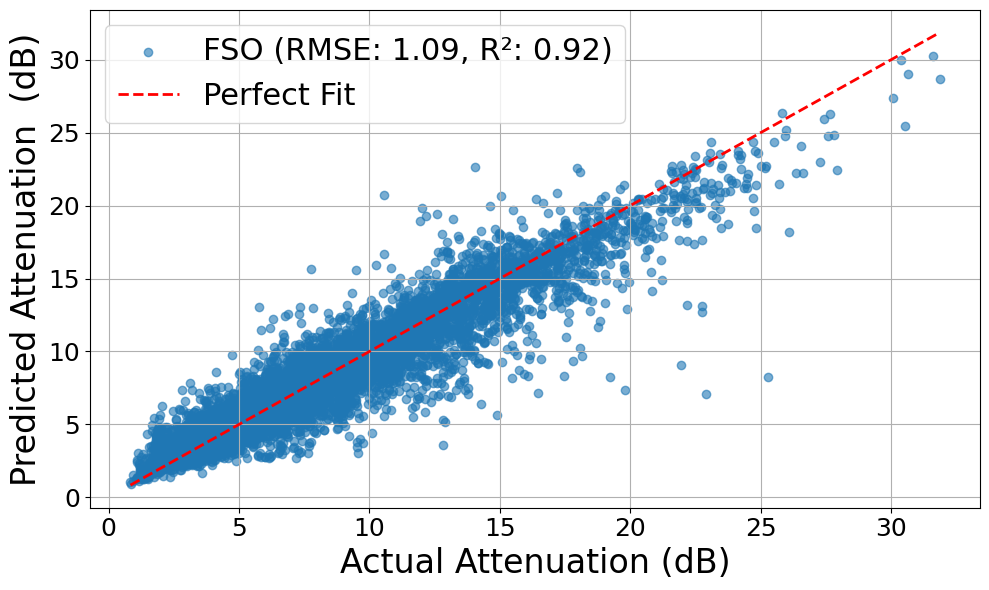

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


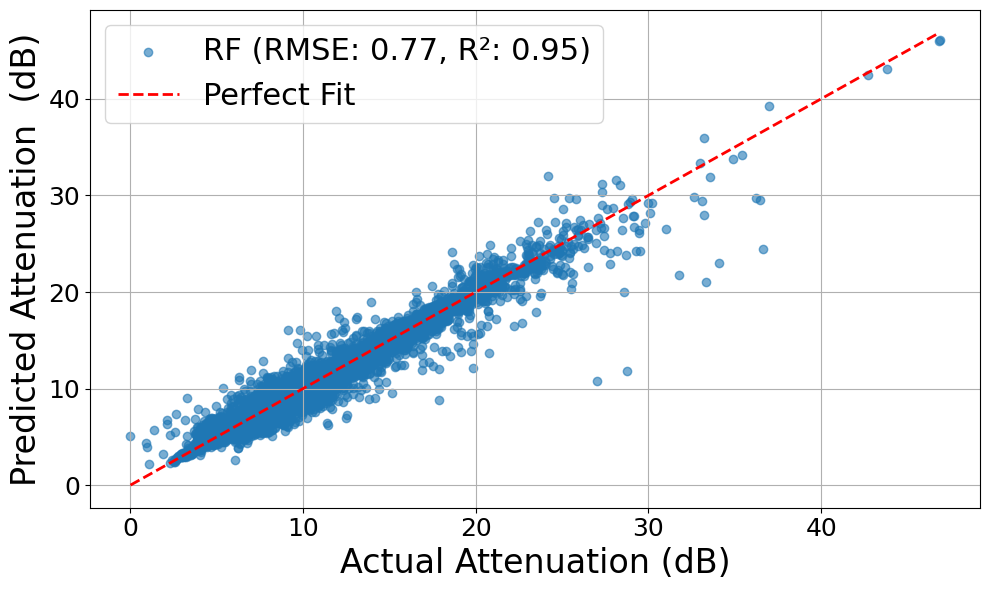

In [12]:

plot_scatter(y_test_fso.values.ravel(), predicted_fso_test, 'FSO', rmse_fso, r2_fso)
plot_scatter(y_test_rf.values.ravel(), predicted_rf_test, 'RF', rmse_rf, r2_rf)